In [ ]:
# === cwd fix: chdir to repo root so relative paths resolve ===
import os, pathlib
_p = pathlib.Path.cwd().resolve()
while _p.parent != _p and not (_p / 'config.yaml').exists():
    _p = _p.parent
if (_p / 'config.yaml').exists():
    os.chdir(_p)
print('cwd:', os.getcwd())

In [29]:
import sys, os, io
sys.path.insert(0, os.path.abspath('.'))

import fitz
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from quill_forge.config.config_loader import ConfigLoader
from quill_forge.data.data_manager import FeathersDataManager
from quill_forge.utils.request_helper import RequestHelper, WorksheetRef
from quill_forge.utils.worksheet_helper import WorksheetHelper
from quill_forge.utils.tag_helper import TagHelper
from quill_forge.client.api_client import FeathersAPIClient

config         = ConfigLoader(environment="feathers")
dm             = FeathersDataManager(config=config)
request_helper = RequestHelper(dm)
helper         = WorksheetHelper(dm, config=config)
tgh            = TagHelper(data_manager=dm, api_client=FeathersAPIClient(), config=config)

DPI_SCALE = 2.0

2026-06-29 16:37:20 INFO quill_forge.config.config_loader: ConfigLoader cache hit: reusing existing instance for env='feathers' (config=config.yaml)
2026-06-29 16:37:20 INFO quill_forge.storage.local_storage.LocalStorage: LocalStorage initialized - Root: /Users/shivam.roy/Desktop/Electrical/data
2026-06-29 16:37:20 INFO quill_forge.data.data_manager.FeathersDataManager: FeathersDataManager initialized - Storage: LocalStorage
2026-06-29 16:37:20 INFO quill_forge.utils.request_helper: RequestHelper initialized
2026-06-29 16:37:20 INFO quill_forge.config.config_loader: ConfigLoader cache hit: reusing existing instance for env='feathers' (config=config.yaml)
2026-06-29 16:37:20 INFO quill_forge.client.api_client.FeathersAPIClient: FeathersAPIClient initialized
2026-06-29 16:37:20 INFO quill_forge.client.api_client.FeathersAPIClient: FeathersAPIClient initialized
2026-06-29 16:37:20 INFO quill_forge.client.data_fetcher.DataFetcher: DataFetcher initialized with hierarchical storage and works

In [30]:
REQUEST_ID   = "0ead8522-b3a9-4bd6-a430-dd0b4dbec6ad"   # ← change me
WORKSHEET_ID = None   # set to a specific wid, or None to pick the first sheet that has legend/schedule

In [31]:
# Resolve LEGEND / SCHEDULE tag IDs for this request
source_tt    = tgh.get_tag_type_by_name(REQUEST_ID, 'source')
source_tt_id = source_tt['id']
legend_id    = tgh.get_tag_by_name(REQUEST_ID, source_tt_id, 'LEGEND')['id']
schedule_id  = tgh.get_tag_by_name(REQUEST_ID, source_tt_id, 'SCHEDULE')['id']
target_ids   = {legend_id, schedule_id}

print(f"LEGEND   : {legend_id}")
print(f"SCHEDULE : {schedule_id}")

LEGEND   : ba6013aa-f0ff-4445-a908-98482ef8915d
SCHEDULE : 7fcac067-78c9-40f5-a096-2034aa8adca5


In [32]:
ref = WorksheetRef(REQUEST_ID, WORKSHEET_ID) if WORKSHEET_ID else request_helper.get_worksheet_refs(REQUEST_ID)[0]

geoms = helper.get_worksheet_geometries(ref)
boxes = []

for out in geoms.get('outputs', []):
    if out.get('feature', {}).get('geometry_type') != 3:
        continue
    for gfeat in out.get('output_geojson', {}).get('features', []):
        tags_info = gfeat.get('properties', {}).get('tags_info', {})
        # check any tags_info entry for legend_id or schedule_id
        matched = next(
            (v.get('tagId') for v in tags_info.values()
             if isinstance(v, dict) and v.get('tagId') in target_ids),
            None
        )
        if not matched:
            continue
        rings = gfeat.get('geometry', {}).get('coordinates', [])
        if rings:
            boxes.append({
                'tag_name': 'LEGEND' if matched == legend_id else 'SCHEDULE',
                'ring': rings[0],
            })

print(f"{len(boxes)} box(es) on wid {ref.worksheet_id[:8]}")
for b in boxes:
    print(f"  {b['tag_name']}")

2026-06-29 16:37:23 INFO quill_forge.utils.request_helper: [0ead8522-b3a9-4bd6-a430-dd0b4dbec6ad] Found 513 worksheets from metadata


0 box(es) on wid 20119607


In [33]:
# Render the worksheet
doc  = fitz.open(helper.get_pdf_path(found_ref))
page = doc.load_page(helper.get_page_number(found_ref) - 1)
pix  = page.get_pixmap(matrix=fitz.Matrix(DPI_SCALE, DPI_SCALE))
img  = np.array(Image.open(io.BytesIO(pix.tobytes("ppm"))))
doc.close()

fe_w, fe_h = helper.get_fe_width_height(found_ref)
sx, sy     = pix.width / fe_w, pix.height / fe_h

print(f"Image shape: {img.shape}")

Image shape: (4768, 6740, 3)


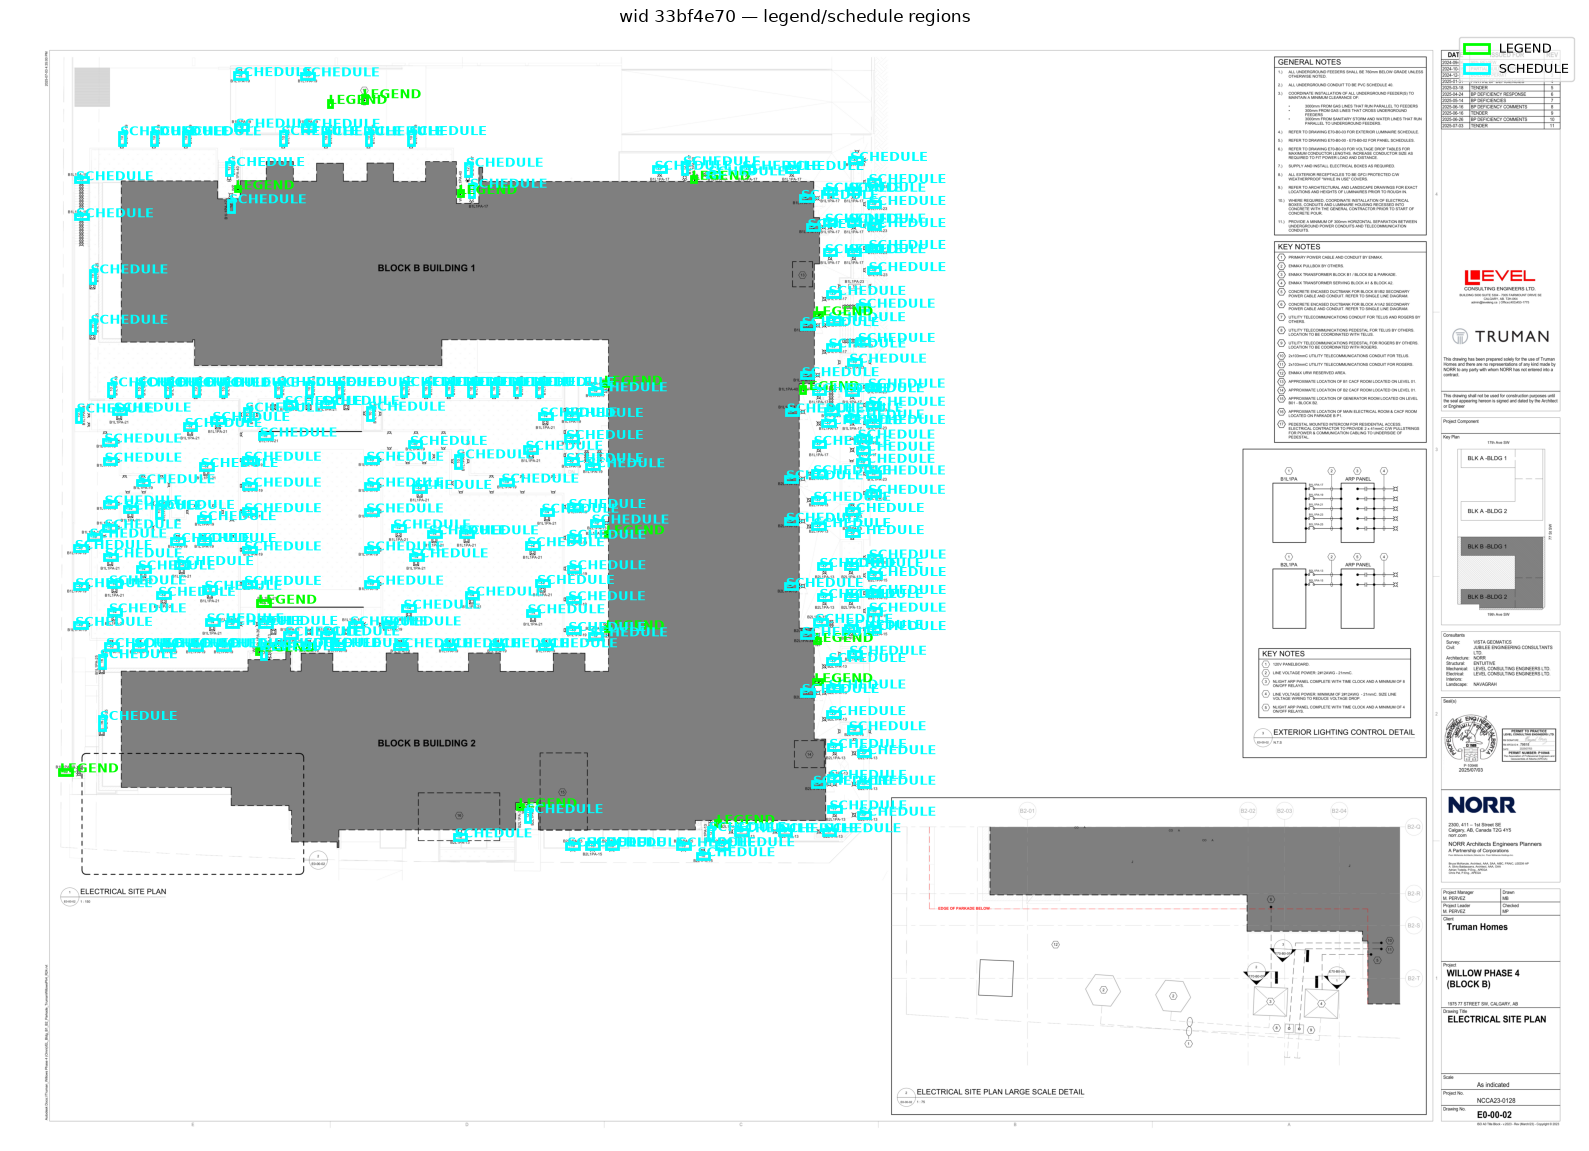

In [34]:
# Plot legend/schedule boxes on the sheet
COLORS = {'LEGEND': 'lime', 'SCHEDULE': 'cyan'}

fig, ax = plt.subplots(figsize=(16, 22))
ax.imshow(img)

for b in found_boxes:
    ring  = b['ring']
    xs    = [int(pt[0] * sx)      for pt in ring]
    ys    = [int(abs(pt[1]) * sy) for pt in ring]
    x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
    color = COLORS.get(b['tag_name'], 'red')
    ax.add_patch(mpatches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor=color, facecolor='none'
    ))
    ax.text(x1+4, y1+16, b['tag_name'], color=color, fontsize=9, fontweight='bold')

handles = [mpatches.Patch(edgecolor=c, facecolor='none', linewidth=2, label=n)
           for n, c in COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=9)
ax.set_title(f"wid {found_ref.worksheet_id[:8]} — legend/schedule regions", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

---\n## Symbol extraction on `table_processing/img1.png`

In [35]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from table_processing.binarize import load_image, binarize
from table_processing.grid_detection import count_black_pixels, find_jumps
from table_processing.connected_components import apply_ccl
from table_processing.legend_extraction import find_first_major_gap, group_components_by_row, shrink_wrap

IMG_PATH = 'table_processing/img1.png'

_, img = load_image(IMG_PATH)
print(f"image shape: {img.shape}")

image shape: (2090, 672, 3)


In [36]:
# Run CCL pipeline
binary          = binarize(img)
bpr, bpc        = count_black_pixels(binary)
_, v_jumps      = find_jumps(bpr, bpc)
labeled, _      = apply_ccl(img)
split_x         = find_first_major_gap(v_jumps, image_width=img.shape[1])
rows            = group_components_by_row(labeled, split_x, image_width=img.shape[1])

# Shrink-wrap symbol column (col_idx == 0) per row
patches = []
for row_idx, row_items in enumerate(rows):
    sym_boxes = [
        item['bbox'] for item in row_items
        if item['col_idx'] == 0 and item['bbox'][2] * item['bbox'][3] >= 15
    ]
    tight = shrink_wrap(sym_boxes)
    if tight is None:
        continue
    cx, cy, cw, ch = tight
    patch = img[cy:cy + ch, cx:cx + cw]
    if patch.size > 0:
        patches.append({'patch': patch, 'bbox': (cx, cy, cx + cw, cy + ch), 'row': row_idx})

print(f"{len(patches)} symbol patches")

60 symbol patches


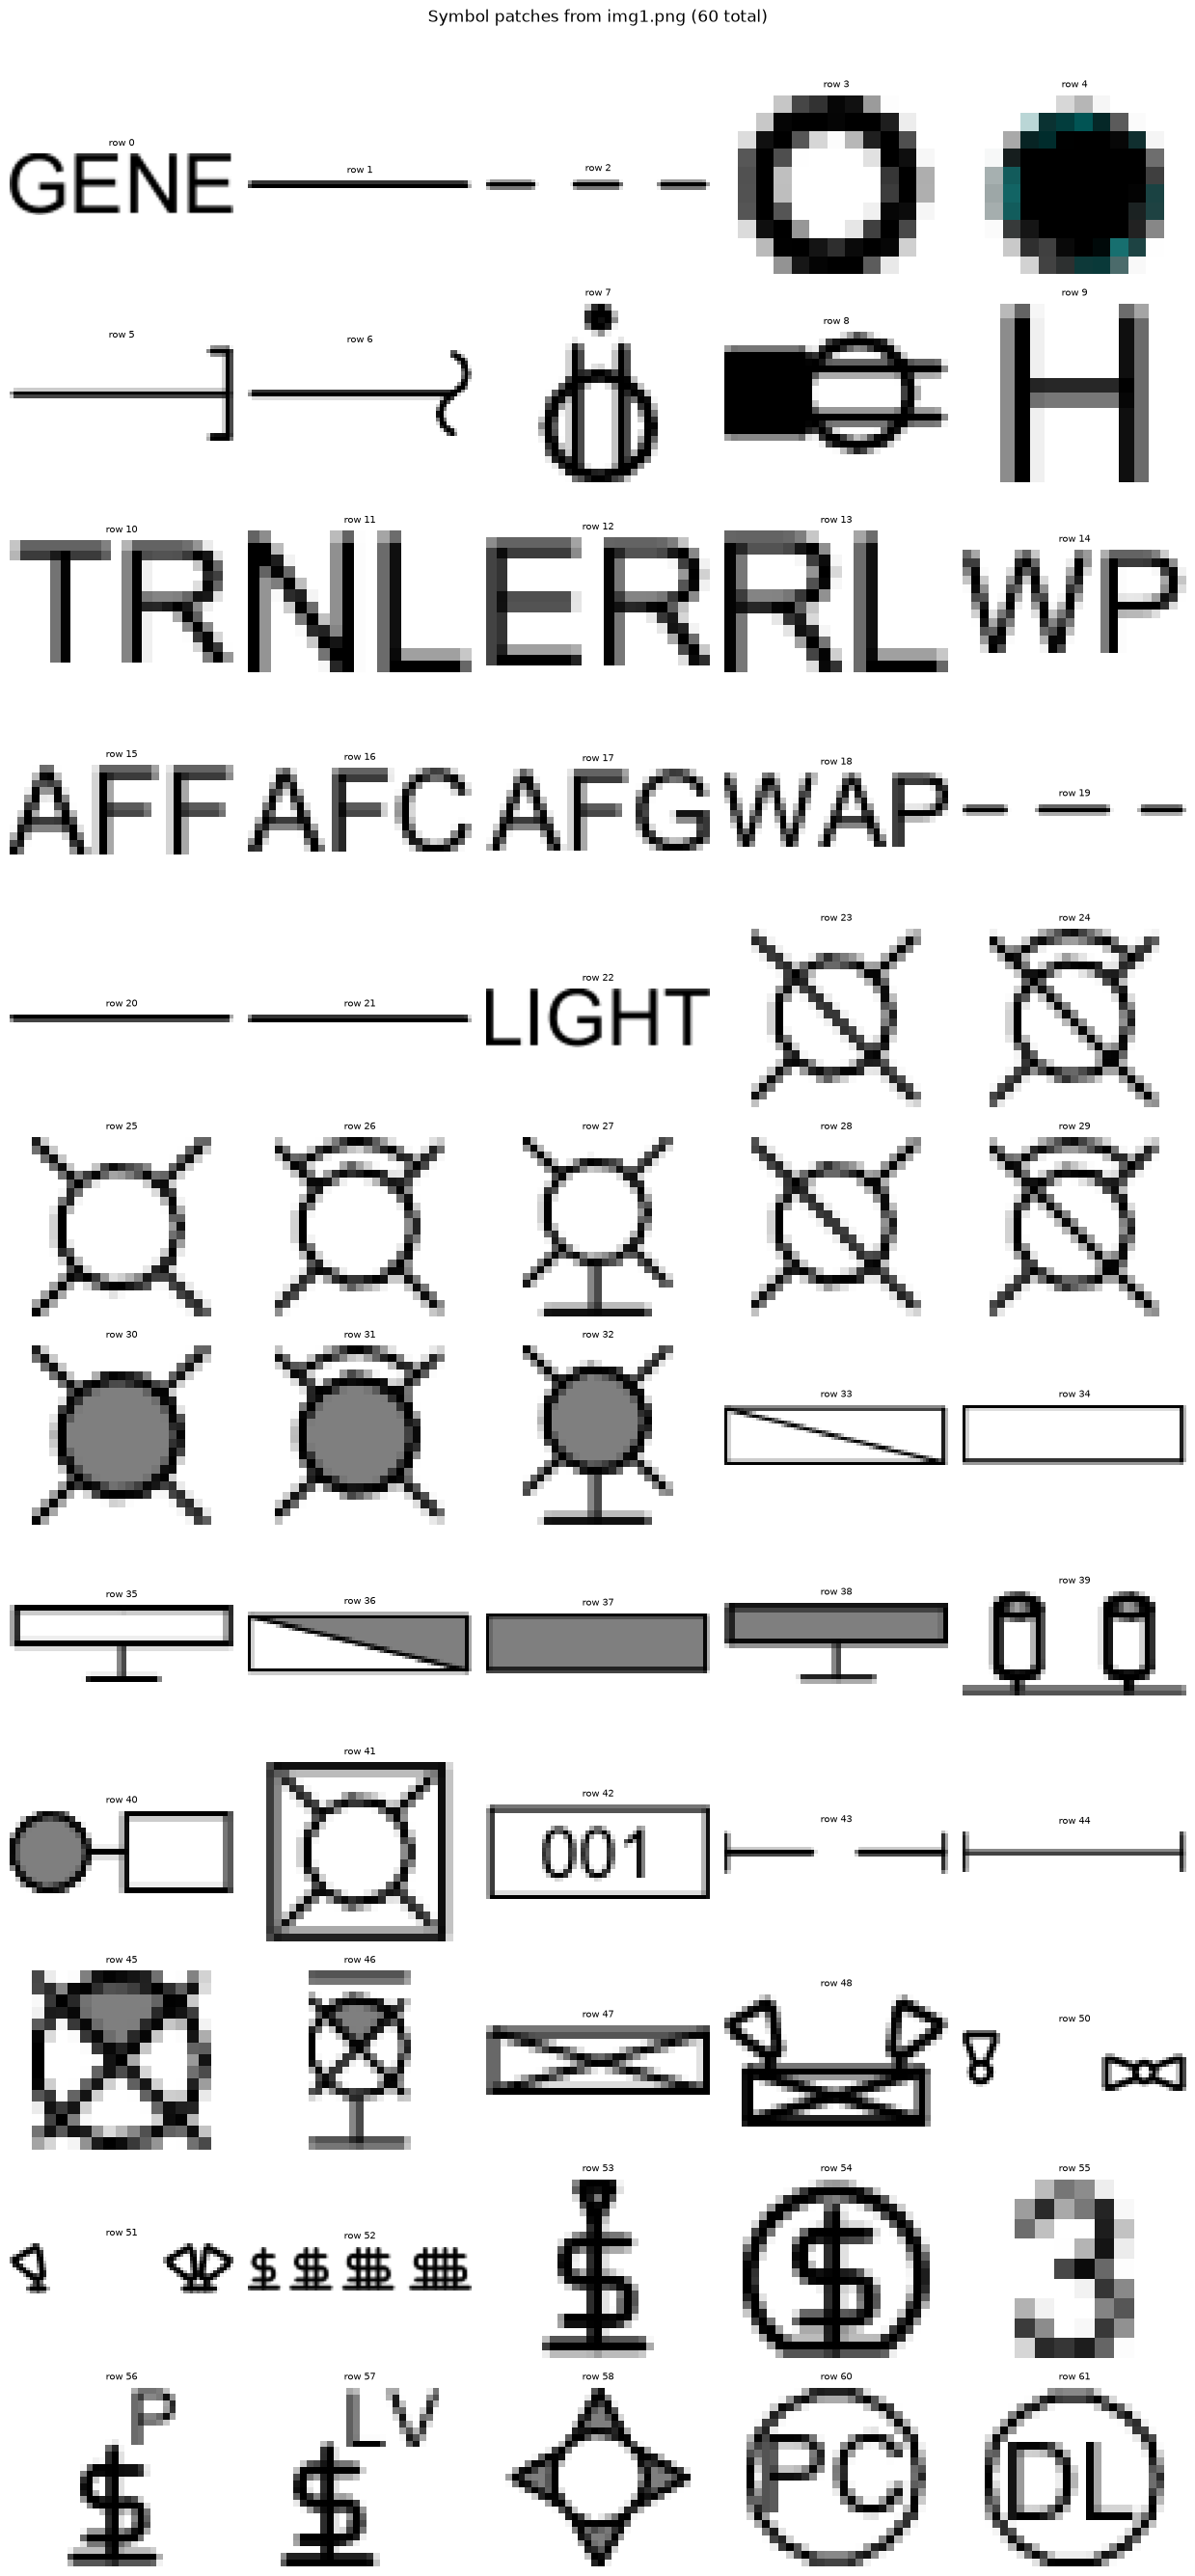

In [37]:
# Patch grid
N_COLS = 5
n      = len(patches)
n_rows = max(1, (n + N_COLS - 1) // N_COLS)

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * 2.5, n_rows * 2.2))
flat = np.array(axes).flatten()

for ax, p in zip(flat, patches):
    ax.imshow(p['patch'])
    ax.set_title(f"row {p['row']}", fontsize=7)
    ax.axis('off')
for ax in flat[n:]:
    ax.axis('off')

plt.suptitle(f'Symbol patches from img1.png ({n} total)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Overlay tight bboxes on the original image
PALETTE = plt.cm.tab20.colors
fig, ax = plt.subplots(figsize=(14, 20))
ax.imshow(img)

for i, p in enumerate(patches):
    x1, y1, x2, y2 = p['bbox']
    ax.add_patch(mpatches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=1.5, edgecolor=PALETTE[i % len(PALETTE)], facecolor='none'
    ))

ax.set_title(f'Tight CCL symbol bboxes on img1.png', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [38]:
OUT_DIR = 'table_processing/symbol_patches'
os.makedirs(OUT_DIR, exist_ok=True)

for p in patches:
    Image.fromarray(p['patch']).save(os.path.join(OUT_DIR, f"row{p['row']:03d}.png"))

print(f"Saved {len(patches)} patches to {OUT_DIR}/")

Saved 60 patches to table_processing/symbol_patches/


---\n## Embeddings + Plotly scatter for symbol patches

In [ ]:
import os, glob, cv2, base64
import numpy as np
import torch
import torchvision.transforms as T
from pathlib import Path
from PIL import Image
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category20_20, Turbo256
from bokeh.embed import file_html
from bokeh.resources import CDN
from IPython.display import display, HTML

PATCH_DIR = 'table_processing/symbol_patches'
targets   = sorted(Path(PATCH_DIR).glob('*.png'))

# ---- build thumbnails ----
THUMB = 80
b64_thumbs = []
for p in tqdm(targets, desc='thumbnails'):
    img = cv2.imread(str(p))
    thumb = cv2.resize(img, (THUMB, THUMB))
    _, buf = cv2.imencode('.png', thumb)
    b64_thumbs.append('data:image/png;base64,' + base64.b64encode(buf).decode())
print(f'{len(b64_thumbs)} thumbnails ready')

In [ ]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model = model.to(device).eval()

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

imgs_pil = [Image.open(p).convert('RGB') for p in targets]
with torch.no_grad():
    batch  = torch.stack([preprocess(img) for img in imgs_pil]).to(device)
    embeds = model(batch).cpu().numpy()

print(f"embeddings: {embeds.shape}")

In [ ]:
coords = TSNE(n_components=2, perplexity=min(10, len(embeds)-1), random_state=42).fit_transform(embeds)

lab_arr = [p.stem for p in targets]   # row000, row001, ...

def plot_tsne_bokeh(coords, lab_arr, thumbs, title, out_html):
    uniq = sorted(set(lab_arr))
    n = len(uniq)
    if n <= 20:
        palette = list(Category20_20[:max(n, 3)])
    else:
        step = max(1, len(Turbo256) // n)
        palette = [Turbo256[i * step % 256] for i in range(n)]
    color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(uniq)}

    source = ColumnDataSource(data=dict(
        x=coords[:, 0].tolist(),
        y=coords[:, 1].tolist(),
        label=lab_arr,
        fname=[p.name for p in targets],
        thumb=thumbs,
        color=[color_map[cls] for cls in lab_arr],
    ))

    p = figure(width=1000, height=750, title=title,
               tools='pan,wheel_zoom,box_zoom,reset,save',
               active_scroll='wheel_zoom')
    p.scatter('x', 'y', source=source, color='color', size=18, alpha=0.85,
              line_color='white', line_width=0.5)
    p.add_tools(HoverTool(tooltips=(
        '<div>'
        '<img src="@thumb" width="100" height="100" '
        'style="border:1px solid #ccc; margin-bottom:4px;"/><br>'
        '<b>@label</b><br>@fname<br>'
        'tsne: (@x{0.1f}, @y{0.1f})'
        '</div>'
    )))

    html = file_html(p, resources=CDN, title=title)
    with open(out_html, 'w') as f:
        f.write(html)
    print(f'Saved: {out_html}')
    display(HTML(f'<iframe srcdoc="{html.replace(chr(34), "&quot;")}" '
                 f'width="1020" height="770" frameborder="0"></iframe>'))

plot_tsne_bokeh(coords, lab_arr, b64_thumbs,
                'Symbol patches — DINOv2 t-SNE',
                'table_processing/symbol_patches_tsne.html')